^C


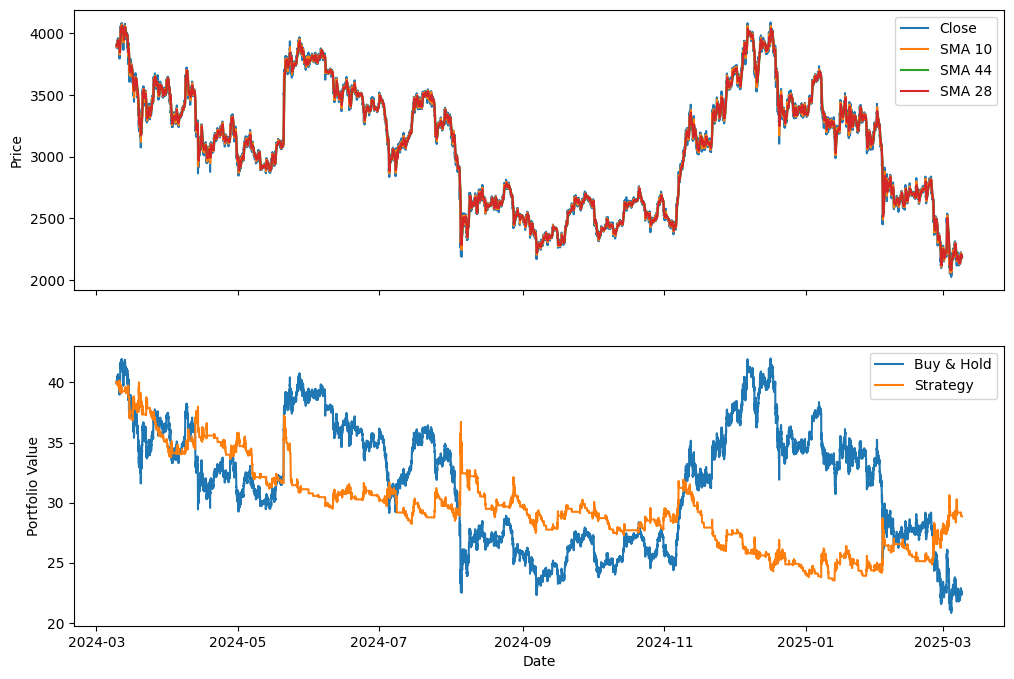

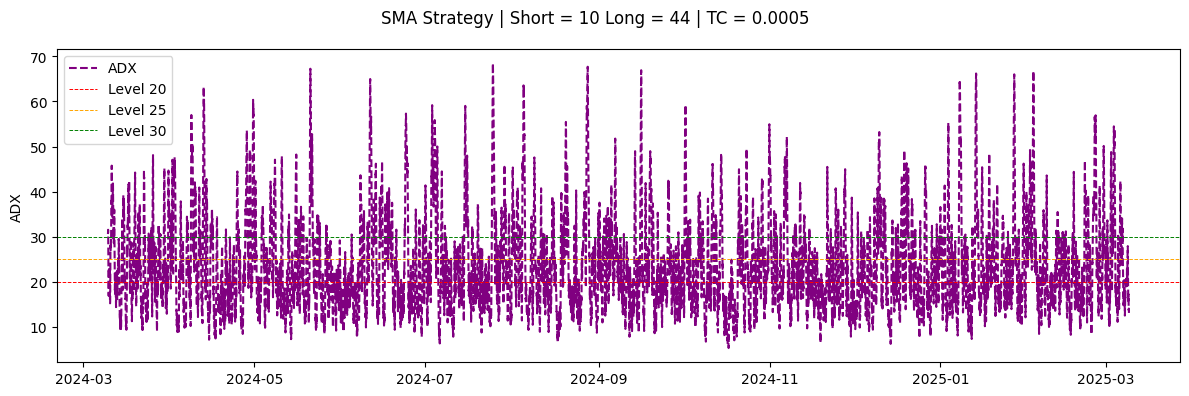

Total Returns: 28.86
Total Trades: 910
Trade Frequency: 0.0260
Maximum Drawdown per Trade: -6.65%
Average Drawdown per Trade: -1.29%
Annualized Sharpe Ratio: -0.62


In [ ]:


# Install pandas_ta if not already installed
!pip install pandas_ta

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import pandas_ta as ta

class Strategy:
    def __init__(self, dataset, short, long, adx, mid, tc=0.0005, amount=40):
        """
        Initialize the Strategy class with trading parameters.

        Args:
            dataset (str): Path to the CSV file with price data.
            short (int): Short SMA period.
            long (int): Long SMA period.
            adx (int): ADX threshold for trend strength.
            mid (int): Mid SMA period.
            tc (float): Transaction cost per trade (default: 0.05%).
            amount (float): Initial portfolio value (default: 40).
        """
        if not isinstance(short, int) or not isinstance(long, int) or short >= long or short <= 0:
            raise ValueError("Short must be a positive integer less than Long")
        self.data = dataset
        self.short = short
        self.long = long
        self.tc = tc
        self.amount = amount
        self.df = None
        self.results = None
        self.original_df = None
        self.adx = adx
        self.mid = mid
        self.max_drawdown = 0
        self.avg_drawdown = 0
        self.annualized_sharpe = np.nan  # Initialize Sharpe ratio as NaN

    def preparedata(self):
        """Load and prepare the dataset from a CSV file."""
        self.df = pd.read_csv(self.data, index_col='timestamp', parse_dates=True)
        self.original_df = self.df.copy()

    def sma_strategy(self):
        """Calculate SMAs, MACD, ATR, and generate buy/sell signals."""
        # Calculate Simple Moving Averages
        self.df['smashort'] = ta.sma(self.df['Close'], length=self.short)
        self.df['smamid'] = ta.sma(self.df['Close'], length=self.mid)
        self.df['smalong'] = ta.sma(self.df['Close'], length=self.long)

        # Calculate MACD (fast=12, slow=26, signal=9)
        macd = ta.macd(self.df['Close'], fast=12, slow=26, signal=9)
        self.df = pd.concat([self.df, macd], axis=1)

        # Calculate ATR (length=14)
        self.df['atr'] = ta.atr(self.df['High'], self.df['Low'], self.df['Close'], length=14)

        # Define buy and sell signals based on SMA crossovers
        self.df['buy'] = (self.df['smashort'] > self.df['smamid']) & (self.df['smamid'] > self.df['smalong'])
        self.df['sell'] = (self.df['smashort'] < self.df['smamid']) & (self.df['smamid'] < self.df['smalong'])

    def ADX(self):
        """Calculate ADX and clean the dataframe by removing NaN values."""
        adx = ta.adx(self.df['High'], self.df['Low'], self.df['Close'], length=20)
        self.df['adx'] = adx['ADX_20']
        # Drop rows where any required indicator is NaN
        self.df.dropna(subset=['smashort', 'smamid', 'smalong', 'MACD_12_26_9', 'MACDs_12_26_9', 'atr', 'adx'], inplace=True)

    def execute_strategy(self):
        """Execute the trading strategy with MACD confirmation and ATR trailing stops."""
        self.df['position'] = 0  # 1 for long, -1 for short, 0 for neutral
        self.df['returns'] = self.df['Close'].pct_change().fillna(0)

        highest_price = None
        lowest_price = None
        stop_loss = None

        for i in range(1, len(self.df)):
            prev_pos = self.df['position'].iloc[i-1]
            Close_price = self.df['Close'].iloc[i]
            atr = self.df['atr'].iloc[i]

            if prev_pos == 1:  # Long position
                highest_price = max(highest_price, Close_price)
                stop_loss = highest_price - 2 * atr  # Trailing stop: 2x ATR below highest price
                if Close_price < stop_loss:
                    self.df.at[self.df.index[i], 'position'] = 0  # Exit long
                    highest_price = None
                    stop_loss = None
                else:
                    self.df.at[self.df.index[i], 'position'] = 1  # Stay long
            elif prev_pos == -1:  # Short position
                lowest_price = min(lowest_price, Close_price)
                stop_loss = lowest_price + 2 * atr  # Trailing stop: 2x ATR above lowest price
                if Close_price > stop_loss:
                    self.df.at[self.df.index[i], 'position'] = 0  # Exit short
                    lowest_price = None
                    stop_loss = None
                else:
                    self.df.at[self.df.index[i], 'position'] = -1  # Stay short
            elif (self.df['buy'].iloc[i] and
                  self.df['MACD_12_26_9'].iloc[i] > self.df['MACDs_12_26_9'].iloc[i] and  # MACD confirmation
                  prev_pos <= 0 and
                  self.df['adx'].iloc[i] > self.adx):  # Trend strength check
                self.df.at[self.df.index[i], 'position'] = 1  # Enter long
                highest_price = Close_price
                stop_loss = Close_price - 2 * atr
            elif (self.df['sell'].iloc[i] and
                  self.df['MACD_12_26_9'].iloc[i] < self.df['MACDs_12_26_9'].iloc[i] and  # MACD confirmation
                  prev_pos >= 0 and
                  self.df['adx'].iloc[i] > self.adx):  # Trend strength check
                self.df.at[self.df.index[i], 'position'] = -1  # Enter short
                lowest_price = Close_price
                stop_loss = Close_price + 2 * atr
            else:
                self.df.at[self.df.index[i], 'position'] = prev_pos  # Maintain previous position

    def result(self):
        """Calculate strategy performance metrics including returns, drawdowns, and Sharpe ratio."""
        self.results = self.df.copy()
        self.results['strategy'] = self.results['position'].shift(1).fillna(0) * self.results['returns']
        self.results['trades'] = self.results['position'].diff().fillna(0).abs()
        self.results['strategy'] = self.results['strategy'] - (self.results['trades'] * self.tc)
        self.results['creturns'] = self.amount * (1 + self.results['returns']).cumprod()
        self.results['cstrategy'] = self.amount * (1 + self.results['strategy']).cumprod()

        # Calculate trade drawdowns
        current_position = 0
        trades = []
        current_trade = None

        for i in range(len(self.results)):
            new_position = self.results['position'].iloc[i]
            if current_position == 0 and new_position != 0:
                current_trade = {
                    'entry_index': i,
                    'direction': new_position,
                    'exit_index': None,
                    'start_returns': i + 1
                }
            elif current_position != 0 and (new_position != current_position or new_position == 0):
                if current_trade is not None:
                    current_trade['exit_index'] = i
                    current_trade['end_returns'] = i
                    trades.append(current_trade)
                    current_trade = None
                if new_position != 0:
                    current_trade = {
                        'entry_index': i,
                        'direction': new_position,
                        'exit_index': None,
                        'start_returns': i + 1
                    }
            current_position = new_position

        if current_trade is not None:
            current_trade['exit_index'] = len(self.results) - 1
            current_trade['end_returns'] = len(self.results) - 1
            trades.append(current_trade)

        self.trade_drawdowns = []
        for trade in trades:
            start = trade['start_returns']
            end = trade['end_returns']
            if start > end or start >= len(self.results) or end >= len(self.results):
                continue
            trade_returns = self.results['strategy'].iloc[start:end+1]
            if len(trade_returns) == 0:
                continue
            cum_returns = (1 + trade_returns).cumprod()
            peak = cum_returns.cummax()
            drawdown = (cum_returns / peak) - 1
            max_dd = drawdown.min()
            self.trade_drawdowns.append(max_dd)

        if self.trade_drawdowns:
            self.max_drawdown = min(self.trade_drawdowns)
            self.avg_drawdown = sum(self.trade_drawdowns) / len(self.trade_drawdowns)
        else:
            self.max_drawdown = 0
            self.avg_drawdown = 0

        # Calculate annualized Sharpe ratio
        daily_cstrategy = self.results['cstrategy'].resample('D').last().dropna()
        if len(daily_cstrategy) > 1:
            daily_returns = daily_cstrategy.pct_change().dropna()
            if len(daily_returns) > 0:
                avg_daily_return = daily_returns.mean()
                std_daily_return = daily_returns.std()
                if std_daily_return > 0:
                    sharpe_ratio = avg_daily_return / std_daily_return
                    self.annualized_sharpe = sharpe_ratio * np.sqrt(365)  # Annualize for crypto (365 days)
                else:
                    self.annualized_sharpe = np.nan
            else:
                self.annualized_sharpe = np.nan
        else:
            self.annualized_sharpe = np.nan

    def plot_result(self):
        """Plot the strategy results including price, SMAs, portfolio value, and ADX."""
        if self.results is None:
            print("Run result() first.")
            return
        try:
            fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
            ax1.plot(self.results.index, self.results['Close'], label='Close')
            ax1.plot(self.results.index, self.results['smashort'], label=f'SMA {self.short}')
            ax1.plot(self.results.index, self.results['smalong'], label=f'SMA {self.long}')
            ax1.plot(self.results.index, self.results['smamid'], label=f'SMA {self.mid}')
            ax1.set_ylabel('Price')
            ax1.legend()

            ax2.plot(self.results.index, self.results['creturns'].dropna(), label='Buy & Hold')
            ax2.plot(self.results.index, self.results['cstrategy'].dropna(), label='Strategy')
            ax2.set_ylabel('Portfolio Value')
            ax2.set_xlabel('Date')
            ax2.legend()

            fig, ax3 = plt.subplots(figsize=(12, 4), sharex=True)
            ax3.plot(self.results.index, self.results['adx'], label='ADX', color='purple', linestyle='--')
            ax3.axhline(y=20, color='red', linestyle='--', linewidth=0.7, label='Level 20')
            ax3.axhline(y=25, color='orange', linestyle='--', linewidth=0.7, label='Level 25')
            ax3.axhline(y=30, color='green', linestyle='--', linewidth=0.7, label='Level 30')
            ax3.set_ylabel('ADX')
            ax3.legend(loc='upper left')

            plt.suptitle(f"SMA Strategy | Short = {self.short} Long = {self.long} | TC = {self.tc}")
            plt.tight_layout()
            plt.show()

            # Print performance metrics
            print(f"Total Returns: {self.results['cstrategy'].iloc[-1]:.2f}")
            print(f"Total Trades: {int(self.results['trades'].sum())}")
            print(f"Trade Frequency: {self.results['trades'].sum() / len(self.results):.4f}")
            print(f"Maximum Drawdown per Trade: {self.max_drawdown:.2%}")
            print(f"Average Drawdown per Trade: {self.avg_drawdown:.2%}")
            if not np.isnan(self.annualized_sharpe):
                print(f"Annualized Sharpe Ratio: {self.annualized_sharpe:.2f}")
            else:
                print("Annualized Sharpe Ratio: N/A")
        except Exception as e:
            print(f"Error in plot_result: {str(e)}")

    def optimize_strategy(self, shortrange, longrange, midrange, adx_range):
        """Optimize strategy parameters based on the Sharpe ratio."""
        combinations = list(product(shortrange, longrange, adx_range, midrange))
        perf = []
        for short, long, adx, mid in combinations:
            if short >= long or short <= 0:
                continue
            self.df = self.original_df.copy()
            self.short = short
            self.long = long
            self.mid = mid
            self.adx = adx
            min_rows_needed = max(self.long, 26)  # Ensure enough data for MACD slow=26
            if len(self.df) < min_rows_needed:
                continue

            self.sma_strategy()
            self.ADX()
            self.execute_strategy()
            self.result()
            if self.results is None:
                continue
            perf.append((short, long, mid, adx, self.annualized_sharpe))

        if not perf:
            raise ValueError("No valid combinations found")

        # Select the best combination based on Sharpe ratio
        best = max(perf, key=lambda x: x[4] if not np.isnan(x[4]) else -np.inf)
        self.short, self.long, self.mid, self.adx = best[0], best[1], best[2], best[3]

        # Run the strategy with the best parameters
        self.df = self.original_df.copy()
        self.sma_strategy()
        self.ADX()
        self.execute_strategy()
        self.result()
        self.plot_result()

        # Print the best parameters and performance
        print(f"Best Combo: Short = {self.short}, Mid = {self.mid}, Long = {self.long}, ADX = {self.adx}")
        print(f"Total Returns: {self.results['cstrategy'].iloc[-1]:.2f}")
        print(f"Total Trades: {int(self.results['trades'].sum())}")
        print(f"Trade Frequency: {self.results['trades'].sum() / len(self.results):.4f}")
        print(f"Maximum Drawdown per Trade: {self.max_drawdown:.2%}")
        print(f"Average Drawdown per Trade: {self.avg_drawdown:.2%}")
        if not np.isnan(self.annualized_sharpe):
            print(f"Annualized Sharpe Ratio: {self.annualized_sharpe:.2f}")
        else:
            print("Annualized Sharpe Ratio: N/A")

# Example usage
try:
    # Initialize the strategy with default parameters
    data = Strategy('ETH1year15min.csv', short=10, long=44, mid=28, adx=26)
    data.preparedata()
    data.sma_strategy()
    data.ADX()
    data.execute_strategy()
    data.result()
    data.plot_result()

    # Uncomment and customize the ranges below to optimize the strategy
    data.optimize_strategy(
         shortrange=range(10, 21, 3),  # e.g., 10, 13, 16, 19
         longrange=range(32, 51, 3),   # e.g., 32, 35, 38, ..., 50
         adx_range=range(20, 41, 3),   # e.g., 20, 23, 26, ..., 40
         midrange=range(20, 31, 2)     # e.g., 20, 22, 24, ..., 30
     )
except Exception as e:
    print(f"Main execution error: {str(e)}")

In [ ]:
import pandas as pd
import numpy as np
import bisect

def detect_pivot_high(source_series, left, right):
    n = len(source_series)
    pivot_highs = [False] * n
    for i in range(n):
        if i < left or i + right >= n:
            continue
        high_val = source_series[i]
        valid = True
        # Check left bars
        for j in range(i - left, i):
            if source_series[j] >= high_val:
                valid = False
                break
        if not valid:
            continue
        # Check right bars
        for j in range(i + 1, i + right + 1):
            if source_series[j] >= high_val:
                valid = False
                break
        if valid:
            pivot_highs[i] = True
    return pivot_highs

def detect_pivot_low(source_series, left, right):
    n = len(source_series)
    pivot_lows = [False] * n
    for i in range(n):
        if i < left or i + right >= n:
            continue
        low_val = source_series[i]
        valid = True
        # Check left bars
        for j in range(i - left, i):
            if source_series[j] <= low_val:
                valid = False
                break
        if not valid:
            continue
        # Check right bars
        for j in range(i + 1, i + right + 1):
            if source_series[j] <= low_val:
                valid = False
                break
        if valid:
            pivot_lows[i] = True
    return pivot_lows

def collect_events(mask, offset, source_values):
    events = []
    n = len(mask)
    for i in range(n):
        if mask[i]:
            event_offset = i + offset
            if event_offset >= n:
                continue
            value = source_values[event_offset]
            events.append((event_offset, value))
    events.sort(key=lambda x: x[0])
    return events

def get_level_values(events, occurrence):
    event_offsets = [e[0] for e in events]
    event_values = [e[1] for e in events]
    n = len(df)
    levels = pd.Series(index=df.index, dtype=np.float64)
    for idx in range(n):
        pos = bisect.bisect_right(event_offsets, idx)
        required_pos = occurrence + 1
        if pos >= required_pos:
            levels.iloc[idx] = event_values[pos - required_pos]
        else:
            levels.iloc[idx] = np.nan
    return levels

# Example usage:
df=pd.read_csv('ETH1year15min.csv')
# Parameters
left = 50
right = 25
quick_right = 5
src = "Close"  # or "High/Low"

# Select source series
if src == "Close":
    source_high = df['Close'].values
    source_low = df['Close'].values
else:
    source_high = df['high'].values
    source_low = df['low'].values

# Detect pivot points
regular_high_mask = detect_pivot_high(source_high, left, right)
regular_low_mask = detect_pivot_low(source_low, left, right)
quick_high_mask = detect_pivot_high(source_high, left, quick_right)
quick_low_mask = detect_pivot_low(source_low, left, quick_right)

# Collect events
quick_high_events = collect_events(quick_high_mask, quick_right, source_high)
quick_low_events = collect_events(quick_low_mask, quick_right, source_low)
regular_high_events = collect_events(regular_high_mask, right, source_high)
regular_low_events = collect_events(regular_low_mask, right, source_low)

# Calculate levels
df['level1'] = get_level_values(quick_high_events, 0)
df['level2'] = get_level_values(quick_low_events, 0)
df['level3'] = get_level_values(regular_high_events, 0)
df['level4'] = get_level_values(regular_low_events, 0)
df['level5'] = get_level_values(regular_high_events, 1)
df['level6'] = get_level_values(regular_low_events, 1)
df['level7'] = get_level_values(regular_high_events, 2)
df['level8'] = get_level_values(regular_low_events, 2)

# Calculate colors
for i in range(1, 9):
    df[f'level{i}_col'] = np.where(df['Close'] >= df[f'level{i}'], 'green', 'red')

# Optional: Plotting code using matplotlib
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 7))
plt.plot(df['Close'], label='Close Price', alpha=0.5)

colors = ['green', 'red']
for i in range(1, 9):
    plt.plot(df[f'level{i}'], color=df[f'level{i}_col'].iloc[-1], linewidth=1, linestyle='--', label=f'Level {i}')

plt.title('Automatic Support & Resistance')
plt.legend()
plt.show()

KeyError: 'close'